In [1]:
from src.analysis import Analysis
from src.config import Config
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize IGREFire

In [3]:
# Analysis Default Config Inputs
# config = Config(
#     analysis_run_title = 'IEEE BUS 30 Basic Run - Extreme Weather - Length-Based Ignitions',
#     ignition_points_distance = 1000,
#     ignition_points_number = 0
# )

# Load config by ID
config = Config(id=3)

# Validate and build the config
config.build()

# Instantiate Analysis Object
analysis = Analysis(config)

                                    IGREFire
Config loaded and validated.
Starting the analysis...
--------------------------------------------------------------------------------
Analysis ID: 3		 Title: IEEE BUS 30 Basic Run - Initial
LCP Resolution: 60	 FARSITE Resolution: 60	 Method: Finney
FARSITE TimeSteps: 60	 Start From: 0		 Periods Hours: 120
Ignition Points: 5	 Distance: 0		 Radius: 40


# Run Analysis

In [4]:
# Option 1: Run a thorough analysis
# analysis.run()

# Option 2: Run individual steps of the analysis
# analysis._generate_inputs()
# analysis._run_simulations()
# analysis._prepare_matpower()
analysis._run_powerflow()

--------------------------------------------------------------------------------
Preparing MATPOWER files...
Preparing MATPOWER files for Scenario #170 -> Branch: 41 - Point: 5 - Weather: Summer

--------------------------------------------------------------------------------
Finished preparing MATPOWER files successfully.


# Data Analysis on Results

In [9]:
columns = analysis.powerflow.scenarios.columns
affect_nodes = [column for column in columns if column.startswith('Affect Node')]
outage_nodes = [column for column in columns if column.startswith('Bus Outage')]

In [4]:
# Disregard unnecessary columns
df = analysis.powerflow.scenarios

In [5]:
df[['Branch', 'Ignition Point', 'Ignition Point X', 'Ignition Point Y', 'Weather', '# Affected Branches', '# Affected Nodes', 'Total Outage', 'Total Positive Outages']].groupby('Branch').mean().sort_values('Total Positive Outages', ascending=False)

/var/folders/c7/4xyyn5wj1rl9z0fs7p5brhs00000gn/T/ipykernel_94879/3853384361.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df[['Branch', 'Ignition Point', 'Ignition Point X', 'Ignition Point Y', 'Weather', '# Affected Branches', '# Affected Nodes', 'Total Outage', 'Total Positive Outages']].groupby('Branch').mean().sort_values('Total Positive Outages', ascending=False)


,Ignition Point,Ignition Point X,Ignition Point Y,# Affected Branches,# Affected Nodes,Total Outage,Total Positive Outages
Branch,,,,,,,
1,3.0,-120.613105,37.756908,1.8,2.8,-89.059906,17.400850
2,3.0,-120.571276,37.762123,1.4,2.4,-87.378451,13.804301
3,3.0,-120.446852,37.685718,2.8,3.8,-63.580223,10.481836
5,3.0,-120.399779,37.672343,2.4,3.4,-66.446464,9.088337
6,3.0,-120.395503,37.686553,2.6,3.6,-66.201669,7.633923
4,3.0,-120.427549,37.764965,3.0,4.4,-82.876566,7.313773
29,3.0,-120.157247,37.814954,1.4,1.8,-79.265354,4.293173
40,3.0,-120.065172,37.862420,2.0,3.0,-84.757192,4.046531
41,3.0,-120.081442,37.864855,1.6,2.4,-78.960611,3.877122


In [20]:
branches = df['Branch'].unique()

# Set reached values to False when Branch is the same as the target point
for i in branches:
    df.loc[df['Branch'] == i, f'Affect Branch {i}'] = False

# Calculate the total number of fire incidents
total_incidents = len(df)
incidents_per_point = df.groupby('Branch').count().iloc[:, 0]  # Choose any column as they all have the same count

# Define a list of column names to consider for the risk and vulnerability calculations
relevant_columns = [f'Affect Branch {i}' for i in branches]

# Calculate the proportion of fire incidents reaching other points for each starting point
reach_prob = df.groupby('Branch')[relevant_columns].sum().div(total_incidents - incidents_per_point, axis=0)

# Calculate the risk: the proportion of incidents where fire reaches all other points for each starting point
risk = reach_prob.sum(axis=1)

# Calculate the vulnerability: the proportion of incidents where fire reaches each point, excluding the ones where the fire started from that point
vulnerability = reach_prob.sum(axis=0)

# Create a new DataFrame with the risk and vulnerability data
result_df = pd.DataFrame({"Branch": risk.index, "risk": risk.values, "vulnerability": vulnerability.values})
result_df = result_df.set_index("Branch")

# Calculate the average outage caused by each point
avg_outage = df.groupby('Branch')[affect_nodes].mean().mean(axis=1)

# Filter out negative values and replace them with NaN
df_positive_damage = df[outage_nodes].where(df[outage_nodes] > 0)

# Calculate the mean value of positive damage induced by fires started from each point
mean_positive_damage = df_positive_damage.groupby(df['Branch']).mean()

# Append the resulting values to the result_df DataFrame
result_df = result_df.join(mean_positive_damage.reset_index(drop=True), on=result_df.index)

# Add the average outage to the result DataFrame
result_df['Average Outage'] = avg_outage

result_df.sort_values('vulnerability')

# Calculate the total outage received by each terrain type from all points
# total_outage = df[outage_nodes].sum()
# print("\nTotal outage to each terrain type:")
# print(total_outage)

,risk,vulnerability,Bus Outage 1,Bus Outage 2,Bus Outage 3,Bus Outage 4,Bus Outage 5,Bus Outage 6,Bus Outage 7,Bus Outage 8,...,Bus Outage 22,Bus Outage 23,Bus Outage 24,Bus Outage 25,Bus Outage 26,Bus Outage 27,Bus Outage 28,Bus Outage 29,Bus Outage 30,Average Outage
Branch,,,,,,,,,,,,,,,,,,,,,
4,0.060606,0.000000,3.407442,NaN,0.000237,0.000238,NaN,NaN,0.000241,0.000240,...,1.198774,NaN,0.000239,NaN,0.000240,2.244695,NaN,0.000239,0.000242,0.146667
31,0.000000,0.000000,1.191639,NaN,0.000245,0.000247,NaN,NaN,0.000248,0.000251,...,0.967228,NaN,0.000246,NaN,0.000244,NaN,NaN,0.000242,0.000243,0.066667
24,0.006061,0.000000,0.503786,NaN,0.000253,0.000254,NaN,NaN,0.000256,0.000256,...,0.203508,NaN,0.000256,NaN,0.000257,NaN,NaN,0.000256,0.000258,0.073333
21,0.006061,0.000000,1.220274,NaN,0.000248,0.000247,NaN,NaN,0.000247,0.000244,...,0.342440,NaN,0.000245,NaN,0.000248,NaN,NaN,0.000249,0.000249,0.060000
23,0.012500,0.006061,0.988082,NaN,0.000235,0.000235,NaN,NaN,0.000237,0.000236,...,0.433795,NaN,0.000235,NaN,0.000237,NaN,NaN,0.000237,0.000239,0.080000
35,0.006061,0.006061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.073333
34,0.006061,0.006061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.060000
37,0.060606,0.012121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.100000
29,0.024242,0.012121,0.229684,NaN,0.000221,0.000223,NaN,NaN,0.000224,0.000224,...,0.342440,NaN,0.000224,NaN,0.000224,NaN,NaN,0.000221,0.000211,0.060000


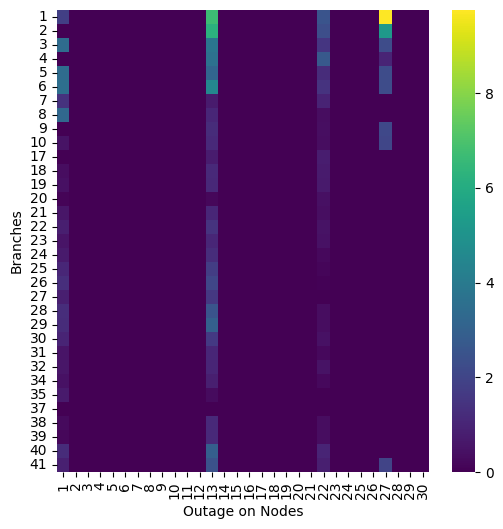

In [43]:
# Select the damage columns in the mean_positive_damage DataFrame
damage_data = mean_positive_damage[outage_nodes]

# Create a heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(damage_data.fillna(0), annot=False, cmap="viridis", xticklabels=[i+1 for i in range(len(outage_nodes))], yticklabels=damage_data.index)

# Set axis labels
plt.xlabel('Outage on Nodes')
plt.ylabel('Branches')

# Show the heatmap
plt.show()

In [ ]:
# Export a coordinated data set based on these dta for each point
# (basically remove unnecessary columns from df)

# Group by branch and Average
# and Extract the same data
# + Average outage per bus
# Weather?
# DOY?

# Create a new df for nodes
# Number of being affected
# Average outage
# Average outage per branch
# Weather?
# DOY?

In [108]:
def temperature_curve(hour):
    # Simulate a daily temperature pattern with a sine wave
    day_hour = hour % 24
    temp_min = 25
    temp_max = 40
    noise = 2
    daily_temp_variation = (temp_max - temp_min) * np.sin((day_hour - 8) * np.pi / 12) / 2
    return temp_min + (temp_max - temp_min) / 2 + daily_temp_variation + random.uniform(-noise, noise)

def humidity_curve(hour):
    # Simulate a daily humidity pattern with a sine wave
    day_hour = hour % 24
    humidity_min = 50
    humidity_max = 70
    noise = 5
    daily_humidity_variation = (humidity_max - humidity_min) * np.sin((day_hour - 18) * np.pi / 12) / 2
    return humidity_min + (humidity_max - humidity_min) / 2 + daily_humidity_variation + random.uniform(-noise, noise)

def wind_speed_curve(hour):
    # Simulate wind speed changing gradually, between 20 and 35
    base_speed = 10
    speed_range = 10
    return base_speed + (speed_range * (1 + np.sin((hour - random.uniform(0, 6)) * np.pi / random.uniform(18, 24))) / 2)

def wind_direction_curve(wind_degree):
    # Simulate noisy wind direction
    direction = wind_degree + random.uniform(-10, 10)
    return direction if direction >= 0 else 360+direction

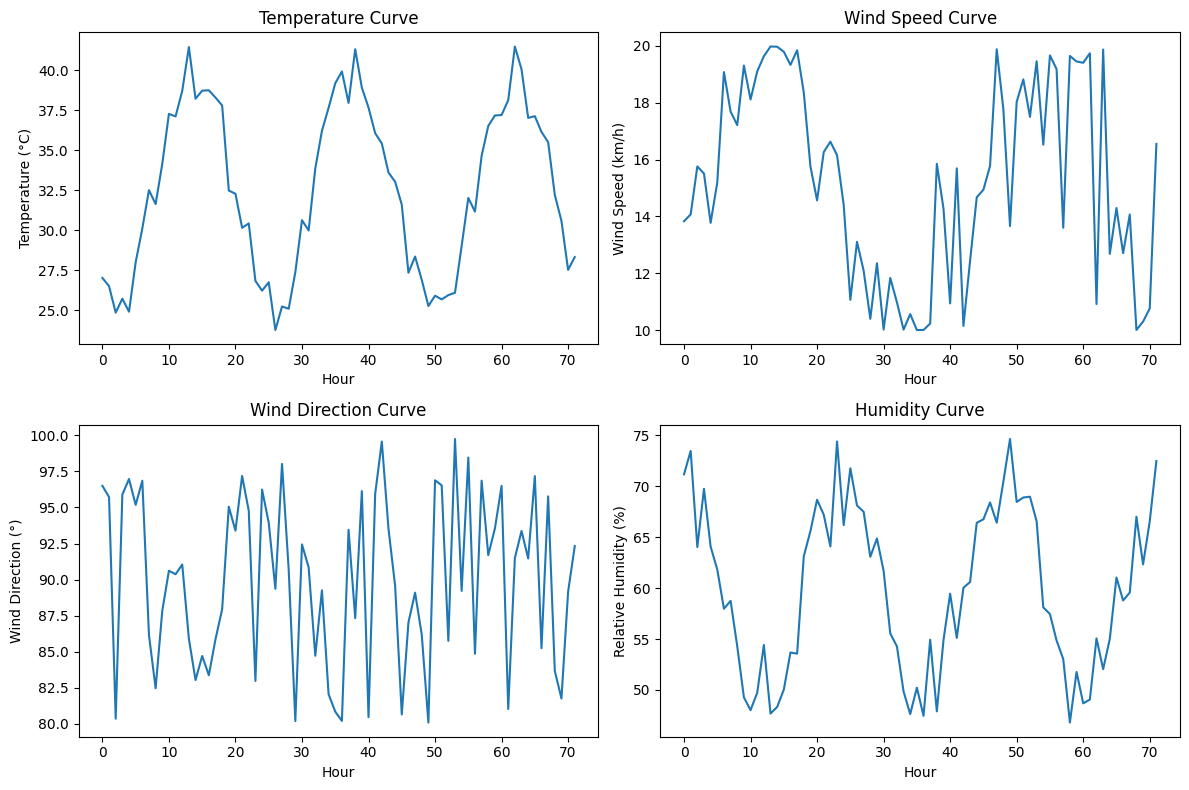

In [112]:
import random
x = np.arange(0, 24*3, 1)

# Calculate the values for each curve
temperature = [temperature_curve(hour) for hour in x]
wind_speed = [wind_speed_curve(hour) for hour in x]
wind_direction = [wind_direction_curve(90) for hour in x]  # Assuming a base wind direction of 90 degrees (East)
humidity = [humidity_curve(hour) for hour in x]

# Plot the curves
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x, temperature)
plt.title('Temperature Curve')
plt.xlabel('Hour')
plt.ylabel('Temperature (°C)')

plt.subplot(2, 2, 2)
plt.plot(x, wind_speed)
plt.title('Wind Speed Curve')
plt.xlabel('Hour')
plt.ylabel('Wind Speed (km/h)')

plt.subplot(2, 2, 3)
plt.plot(x, wind_direction)
plt.title('Wind Direction Curve')
plt.xlabel('Hour')
plt.ylabel('Wind Direction (°)')

plt.subplot(2, 2, 4)
plt.plot(x, humidity)
plt.title('Humidity Curve')
plt.xlabel('Hour')
plt.ylabel('Relative Humidity (%)')

plt.tight_layout()
plt.show()